# ERA V5 · Session 12 — ZeRO on 32 virtual GPUs, by hand

32 CPU processes stand in for 32 GPUs and talk through `torch.distributed` (gloo) with the same three
collectives a real run uses: all-reduce, reduce-scatter, all-gather. A tiny GPT trains on top of them
under data parallelism (stage 0) and ZeRO stages 1, 2 and 3. No DeepSpeed, no FSDP: each stage is the
collectives called in the right order, in `zero_sim.py`.

Everything below runs live. Runs on CPU; no GPU needed.

In [1]:
import os, sys, json
if not os.path.exists('zero_sim.py'):             # on Colab: fetch the code
    !git clone -q https://github.com/sandeepkunkunuru/era-v5.git 2>/dev/null || true
    os.chdir('era-v5/session-12-zero')
sys.path.insert(0, os.getcwd())
import torch, zero_sim as Z
Z.FIGDIR = Z.HERE / 'figures' / 'notebook'       # keep the full run's figures untouched
Z.load_text()
print('torch', torch.__version__, '| CPU threads', os.cpu_count())

torch 2.12.1+cu130 | CPU threads 16


## What each stage keeps on every GPU

| stage | weights (bf16, 2 B) | gradients (bf16, 2 B) | fp32 copy + Adam m, v (12 B) | bytes / parameter at W GPUs |
|---|---|---|---|---|
| 0 (data parallel) | all | all | all | 16 |
| 1 | all | all | 1/W | 4 + 12/W |
| 2 | all | 1/W | 1/W | 2 + 14/W |
| 3 | 1/W | 1/W | 1/W | 16/W |

The run below measures these by walking the tensors each process actually holds.

## Run all four stages on 32 virtual GPUs

In [2]:
W, STEPS = 32, 6
runs = []
for stage in range(4):
    s = Z.summarise(Z.run(W, stage, STEPS, 29800 + stage))
    runs.append(s)
    print(f"stage {stage}: {s['bytes_per_param']:5.2f} B/param per GPU (formula {Z.theory(stage, W):5.2f}) | "
          f"traffic {s['traffic_total_P']:.3f} P/step | optimizer {1000*s['time']['optimizer']:.2f} ms | "
          f"loss after {STEPS} steps {s['losses'][-1]:.4f}")

stage 0: 16.00 B/param per GPU (formula 16.00) | traffic 1.938 P/step | optimizer 19.04 ms | loss after 6 steps 3.4752


stage 1:  4.38 B/param per GPU (formula  4.38) | traffic 1.938 P/step | optimizer 0.85 ms | loss after 6 steps 3.4752


stage 2:  2.44 B/param per GPU (formula  2.44) | traffic 1.938 P/step | optimizer 0.97 ms | loss after 6 steps 3.4752


stage 3:  0.50 B/param per GPU (formula  0.50) | traffic 2.868 P/step | optimizer 0.95 ms | loss after 6 steps 3.4753


## Did the sharding change what the model learned?

One process, trained on the whole global batch of 32 x 4 sequences. All five loss curves must agree.

In [3]:
ref = Z.reference(STEPS, W)
print('step  one-process  ' + '  '.join(f'stage {s["stage"]}' for s in runs))
for i in range(STEPS):
    print(f'{i+1:>4}  {ref[i]:11.4f}  ' + '  '.join(f'{s["losses"][i]:7.4f}' for s in runs))
print('largest difference:', {s['stage']: f"{max(abs(a - b) for a, b in zip(s['losses'], ref)):.1e}" for s in runs})

step  one-process  stage 0  stage 1  stage 2  stage 3
   1       4.2025   4.2025   4.2025   4.2025   4.2025
   2       3.8288   3.8287   3.8287   3.8287   3.8287
   3       3.6859   3.6858   3.6858   3.6858   3.6858
   4       3.6240   3.6240   3.6240   3.6240   3.6240
   5       3.5438   3.5437   3.5437   3.5437   3.5437
   6       3.4753   3.4752   3.4752   3.4752   3.4753
largest difference: {0: '1.0e-04', 1: '1.0e-04', 2: '1.0e-04', 3: '5.7e-05'}


## Memory and time per GPU

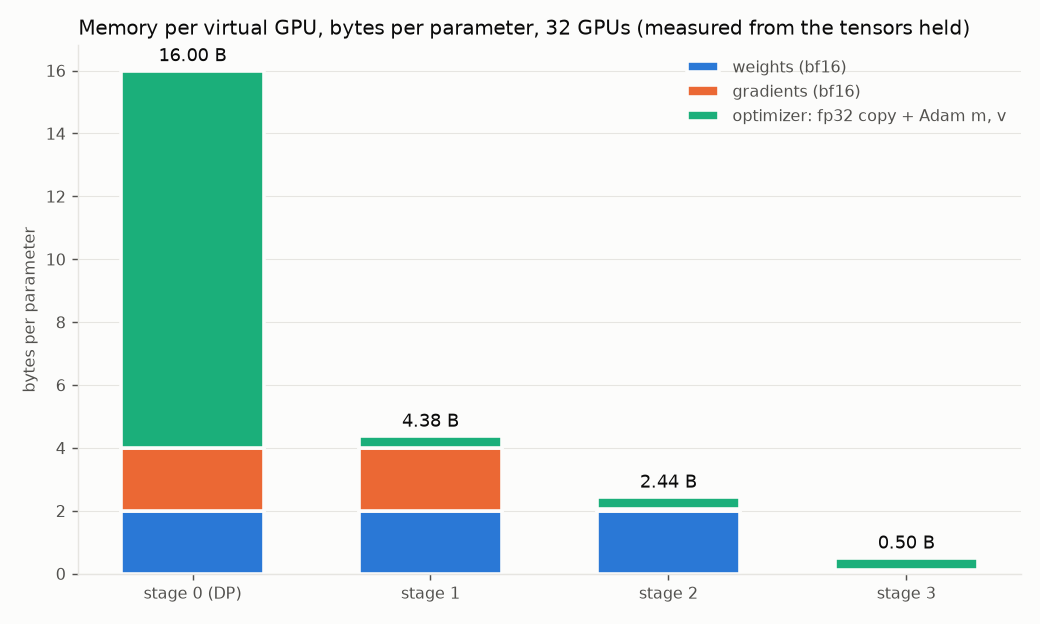

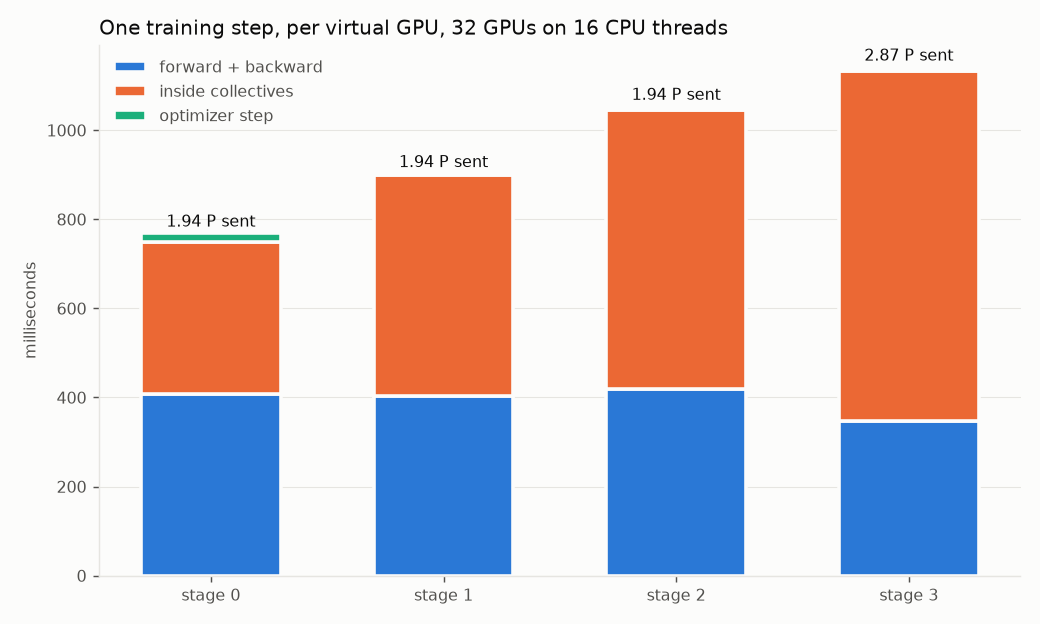

In [4]:
from IPython.display import Image, display
R = dict(worlds=[W], runs=runs, N=runs[0]['N'], cpu_threads=os.cpu_count())
Z.plot_all(R)
display(Image(filename=str(Z.FIGDIR / 'memory_by_stage.png')))
display(Image(filename=str(Z.FIGDIR / 'time_by_stage.png')))

## Communication, collective by collective

In units of P, the whole model in bf16. The ring volumes are 2(W-1)/W for all-reduce and (W-1)/W for
reduce-scatter and all-gather, so stages 0-2 come to 2(W-1)/W and stage 3 to just under 3(W-1)/W
(the embeddings need no weights in backward, so they skip one gather).

In [5]:
for s in runs:
    print(f"stage {s['stage']}: ", {k: round(v, 3) for k, v in s['traffic_P'].items()}, '| calls', s['calls'])

stage 0:  {'all_reduce': 1.938, 'reduce_scatter': 0.0, 'all_gather': 0.0} | calls {'all_reduce': 11, 'reduce_scatter': 0, 'all_gather': 0}
stage 1:  {'all_reduce': 0.0, 'reduce_scatter': 0.969, 'all_gather': 0.969} | calls {'all_reduce': 0, 'reduce_scatter': 11, 'all_gather': 11}
stage 2:  {'all_reduce': 0.0, 'reduce_scatter': 0.969, 'all_gather': 0.969} | calls {'all_reduce': 0, 'reduce_scatter': 11, 'all_gather': 11}
stage 3:  {'all_reduce': 0.0, 'reduce_scatter': 0.969, 'all_gather': 1.899} | calls {'all_reduce': 0, 'reduce_scatter': 11, 'all_gather': 20}
